# Exploratory Data Analysis

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Establishing a connection to the MySQL database
!pip install pymysql sqlalchemy 
from sqlalchemy import create_engine
username = 'root'
password = 'shivam8890'
host = 'localhost'
port = '3306'
database = 'HR_Employee_DB'
engine = create_engine(f'mysql+pymysql://{username}:{password}@{host}:{port}/{database}')
df=pd.read_sql('select * from HR_Employees_data', engine)

In [4]:
df.head()

,EmpID,Employee_Name,Sex,MaritalDesc,DeptID,FromDiversityJobFairID,Salary,Position,State,Zip,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,10026,Wilson K Adinolfi,M,Single,5,0,62506,Production Technician I,MA,1960,...,Michael Albert,22,LinkedIn,Exceeds,4.60,5,0,2019-01-17,0,1
1,10084,Karthikeyan Ait Sidi,M,Married,3,0,104437,Sr. DBA,MA,2148,...,Simon Roup,4,Indeed,Fully Meets,4.96,3,6,2016-02-24,0,17
2,10196,Sarah Akinkuolie,F,Married,5,0,64955,Production Technician II,MA,1810,...,Kissy Sullivan,20,LinkedIn,Fully Meets,3.02,3,0,2012-05-15,0,3
3,10088,Trina Alagbe,F,Married,5,0,64991,Production Technician I,MA,1886,...,Elijiah Gray,16,Indeed,Fully Meets,4.84,5,0,2019-01-03,0,15
4,10069,Carol Anderson,F,Divorced,5,0,50825,Production Technician I,MA,2169,...,Webster Butler,39,Google Search,Fully Meets,5.00,4,0,2016-02-01,0,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   EmpID                       311 non-null    int64  
 1   Employee_Name               311 non-null    object 
 2   Sex                         311 non-null    object 
 3   MaritalDesc                 311 non-null    object 
 4   DeptID                      311 non-null    int64  
 5   FromDiversityJobFairID      311 non-null    int64  
 6   Salary                      311 non-null    int64  
 7   Position                    311 non-null    object 
 8   State                       311 non-null    object 
 9   Zip                         311 non-null    int64  
 10  DOB                         311 non-null    object 
 11  CitizenDesc                 311 non-null    object 
 12  HispanicLatino              311 non-null    object 
 13  RaceDesc                    311 non

In [6]:
date_columns = ['DOB', 'DateofHire', 'DateofTermination', 'LastPerformanceReview_Date']
# I changed the date colunms data type to datecolumns
for i in date_columns:
    df[i] = pd.to_datetime(df[i])
# changed the data type of salary column to float from object type
df['Salary'] = df['Salary'].astype('float')

In [7]:
# summary statistics
df.describe(include = 'all')

,EmpID,Employee_Name,Sex,MaritalDesc,DeptID,FromDiversityJobFairID,Salary,Position,State,Zip,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
count,311.000000,311,311,311,311.000000,311.000000,311.000000,311,311,311.000000,...,311,311.000000,311,311,311.000000,311.000000,311.000000,311,311.000000,311.000000
unique,NaN,311,2,5,NaN,NaN,NaN,32,28,NaN,...,21,NaN,9,4,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Wilson K Adinolfi,F,Single,NaN,NaN,NaN,Production Technician I,MA,NaN,...,Michael Albert,NaN,Indeed,Fully Meets,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,176,137,NaN,NaN,NaN,137,276,NaN,...,22,NaN,87,243,NaN,NaN,NaN,NaN,NaN,NaN
mean,10156.000000,NaN,NaN,NaN,4.610932,0.093248,69020.684887,NaN,NaN,6555.482315,...,NaN,15.199357,NaN,NaN,4.110000,3.890675,1.218650,2017-09-10 21:17:56.527331072,0.414791,10.237942
min,10001.000000,NaN,NaN,NaN,1.000000,0.000000,45046.000000,NaN,NaN,1013.000000,...,NaN,1.000000,NaN,NaN,1.120000,1.000000,0.000000,2010-07-14 00:00:00,0.000000,1.000000
25%,10078.500000,NaN,NaN,NaN,5.000000,0.000000,55501.500000,NaN,NaN,1901.500000,...,NaN,10.000000,NaN,NaN,3.690000,3.000000,0.000000,2016-03-19 12:00:00,0.000000,5.000000
50%,10156.000000,NaN,NaN,NaN,5.000000,0.000000,62810.000000,NaN,NaN,2132.000000,...,NaN,16.000000,NaN,NaN,4.280000,4.000000,0.000000,2019-01-16 00:00:00,0.000000,10.000000
75%,10233.500000,NaN,NaN,NaN,5.000000,0.000000,72036.000000,NaN,NaN,2355.000000,...,NaN,19.500000,NaN,NaN,4.700000,5.000000,0.000000,2019-02-04 00:00:00,0.000000,15.000000
max,10311.000000,NaN,NaN,NaN,6.000000,1.000000,250000.000000,NaN,NaN,98052.000000,...,NaN,39.000000,NaN,NaN,5.000000,5.000000,8.000000,2019-02-28 00:00:00,6.000000,20.000000


In [8]:
# Frequency of categorical variables
df.Sex.value_counts()

Sex
F     176
M     135
Name: count, dtype: int64

In [9]:
df.MaritalDesc.value_counts()

MaritalDesc
Single       137
Married      124
Divorced      30
Separated     12
Widowed        8
Name: count, dtype: int64

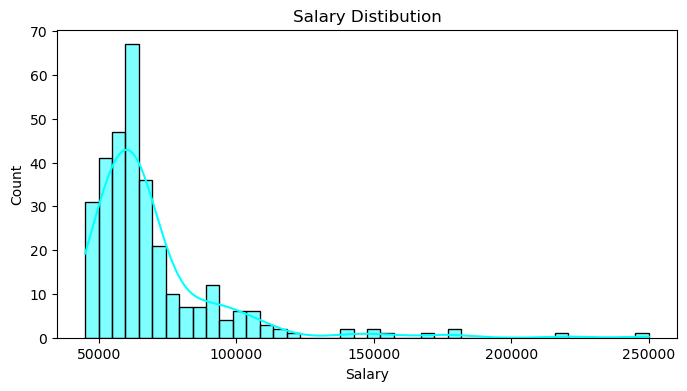

In [10]:
plt.figure(figsize = (8, 4))

sns.histplot(df.Salary, kde=True, color = 'cyan')
plt.title('Salary Distibution')
plt.show()

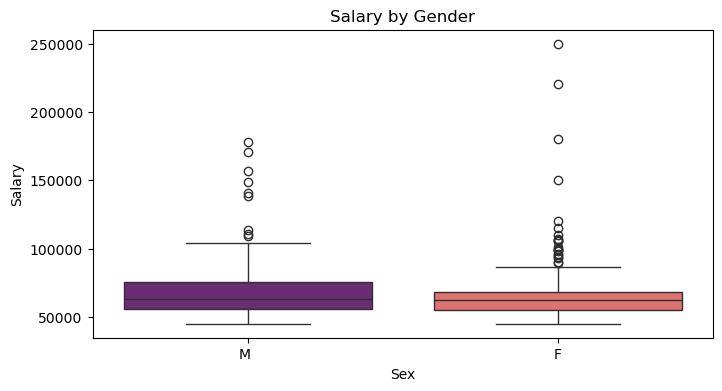

In [11]:
plt.figure(figsize = (8, 4))

sns.boxplot(x = 'Sex', y = 'Salary', data=df, palette='magma')
plt.title('Salary by Gender')
plt.show()

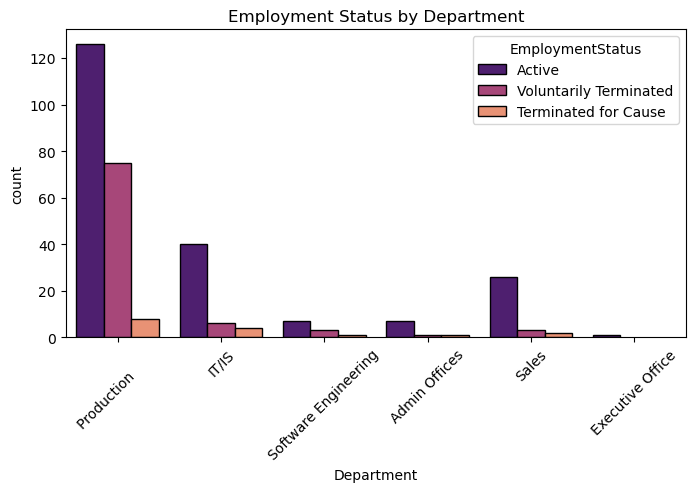

In [12]:
plt.figure(figsize = (8, 4))

sns.countplot(x = 'Department', hue = 'EmploymentStatus', data=df, palette='magma', edgecolor='black')
plt.title('Employment Status by Department')
plt.xticks(rotation=45)
plt.show()

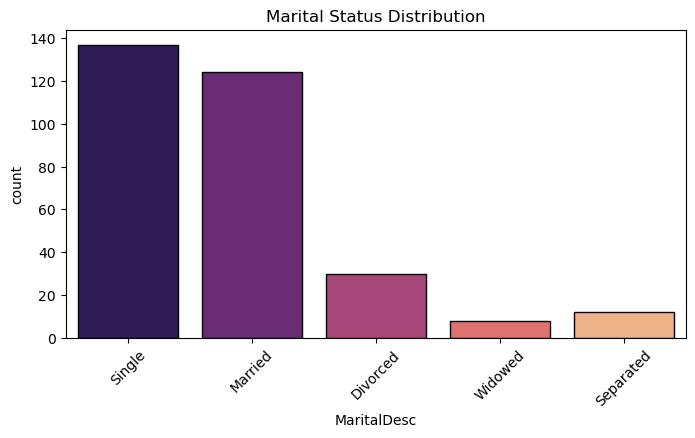

In [13]:
plt.figure(figsize = (8, 4))

sns.countplot(x = 'MaritalDesc', data=df, palette='magma', edgecolor='black')
plt.title('Marital Status Distribution')
plt.xticks(rotation=45)
plt.show()

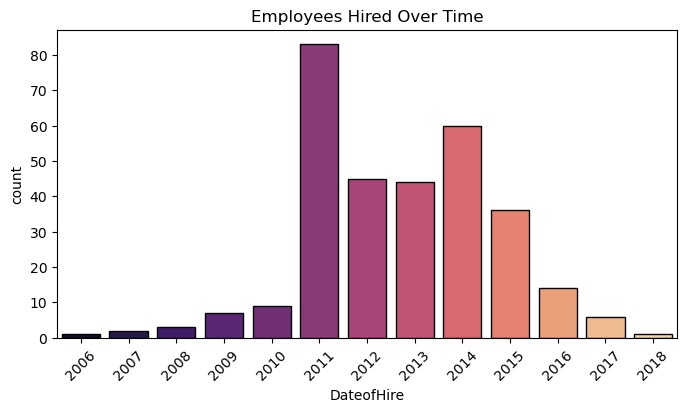

In [14]:
plt.figure(figsize = (8, 4))

sns.countplot(x = df['DateofHire'].dt.year, palette='magma', edgecolor='black')
plt.title('Employees Hired Over Time')
plt.xticks(rotation=45)
plt.show()

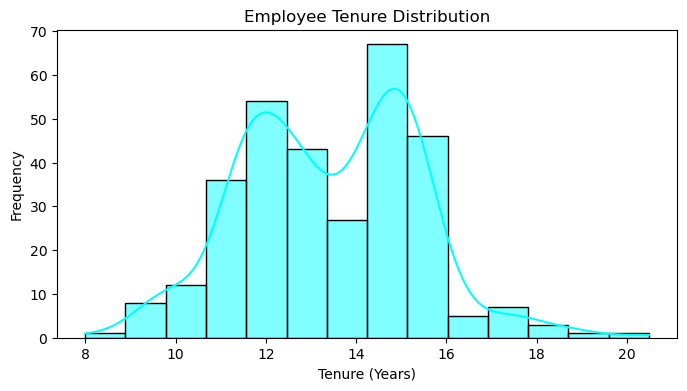

In [15]:
df['Tenure'] = (pd.to_datetime('today') - df['DateofHire']).dt.days / 365.25
plt.figure(figsize=(8, 4))
sns.histplot(df['Tenure'], color = 'cyan', kde=True, edgecolor = 'black')
plt.title('Employee Tenure Distribution')
plt.xlabel('Tenure (Years)')
plt.ylabel('Frequency')
plt.show()

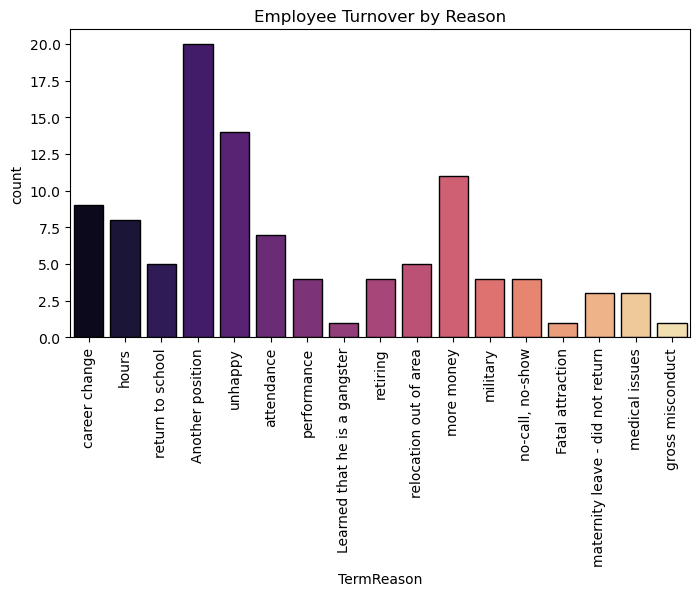

In [16]:
plt.figure(figsize = (8, 4))
sns.countplot(x = 'TermReason', data = df[df.TermReason != 'N/A-StillEmployed'], palette='magma', edgecolor='black')
plt.title('Employee Turnover by Reason')
plt.xticks(rotation=90)
plt.show()

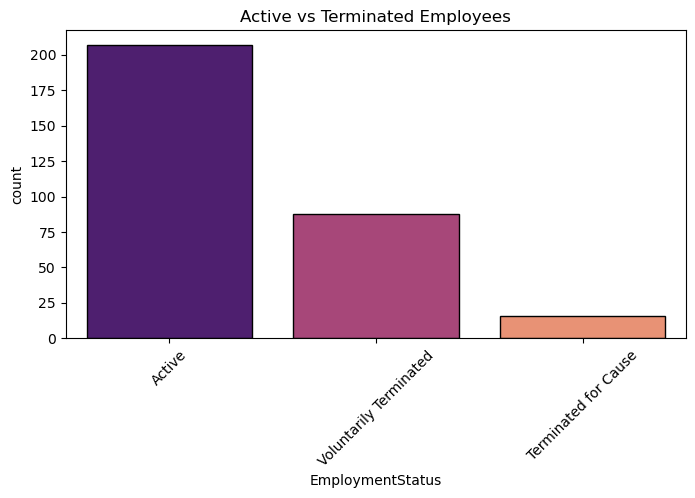

In [17]:
plt.figure(figsize = (8, 4))
sns.countplot(x = 'EmploymentStatus', data = df, palette='magma', edgecolor='black')
plt.title('Active vs Terminated Employees')
plt.xticks(rotation=45)
plt.show()

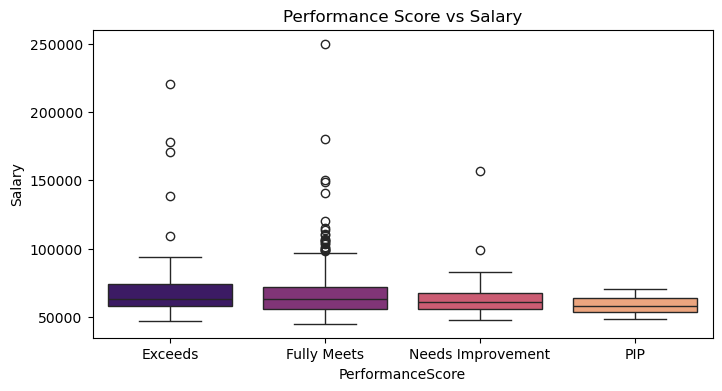

In [18]:
plt.figure(figsize = (8, 4))
sns.boxplot(x = 'PerformanceScore', y = 'Salary', data=df, palette='magma')
plt.title('Performance Score vs Salary')
plt.show()

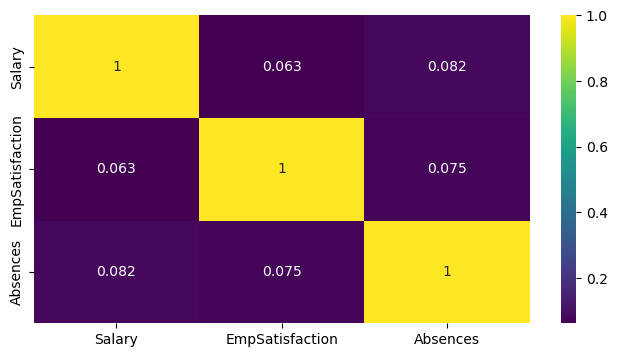

In [19]:
plt.figure(figsize = (8, 4))
correlation = df[['Salary', 'EmpSatisfaction', 'Absences']].corr()
sns.heatmap(correlation, annot=True, cmap='viridis')
plt.show()

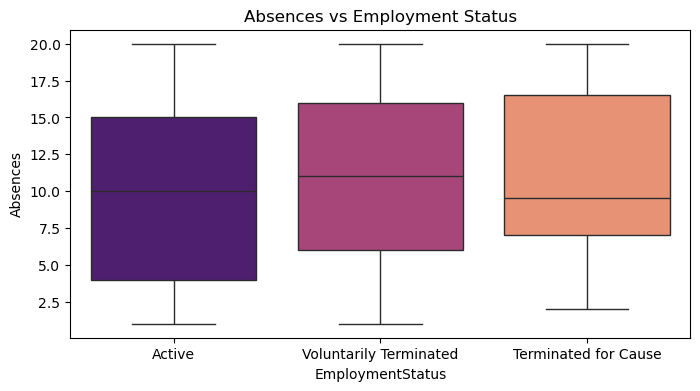

In [20]:
plt.figure(figsize = (8, 4))
sns.boxplot(x = 'EmploymentStatus', y = 'Absences', data=df, palette='magma')
plt.title('Absences vs Employment Status')
plt.show()

<Figure size 800x500 with 0 Axes>

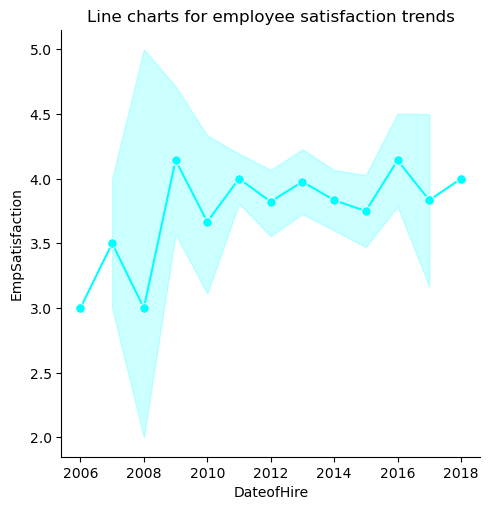

In [21]:
plt.figure(figsize = (8, 5))
sns.relplot(x = df['DateofHire'].dt.year, y = 'EmpSatisfaction', data=df, 
            kind = 'line', marker='o',color = 'cyan', markersize=7)
plt.title('Line charts for employee satisfaction trends')
plt.show()

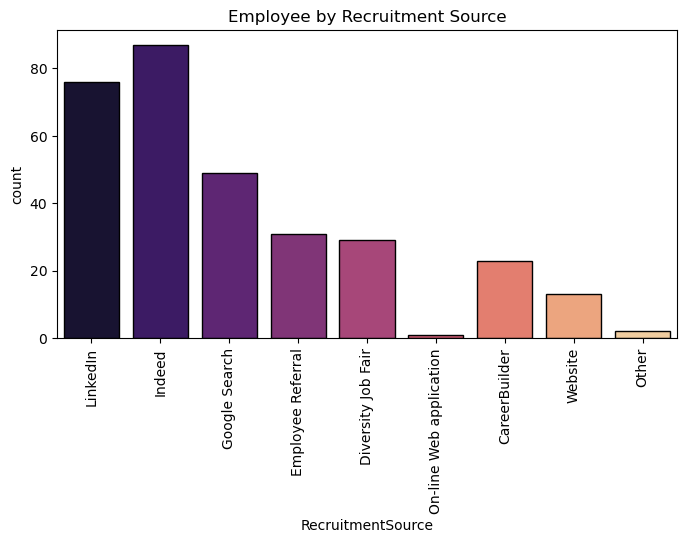

In [22]:
plt.figure(figsize = (8, 4))
sns.countplot(x = 'RecruitmentSource', data = df, palette='magma', edgecolor='black')
plt.title('Employee by Recruitment Source')
plt.xticks(rotation=90)
plt.show()